# Club Analytics
This project is about analyzing players that I used during my FIFA/EAFC Career modes since FIFA 12.

This specific Notebook is about analyzing the clubs that I used during the career modes.

In [1]:
# Basic settings for the notebook
import matplotlib.pyplot as plt
import seaborn as sns
import sys

project_root = r"C:\Users\Martijn\PycharmProjects\CareerLegacy"

if project_root not in sys.path:
    sys.path.append(project_root)

from Analytics.AnalyticsTooling import AnalyticsTooling

# Generic Tooling for analytics
analytic_tools = AnalyticsTooling()

C:\Users\Martijn\PycharmProjects\CareerLegacy\Analytics\AnalyticsTooling.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  self.dataframes["df_person_info"] = pandas.read_sql(query, con=self.sql_handler.connection)
C:\Users\Martijn\PycharmProjects\CareerLegacy\Analytics\AnalyticsTooling.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  self.dataframes["df_player_info"] = pandas.read_sql(query, con=self.sql_handler.connection)
C:\Users\Martijn\PycharmProjects\CareerLegacy\Analytics\AnalyticsTooling.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Ple

In [2]:
# Get the dataframes
dataframe_dict = analytic_tools.dataframes
df_person_info = dataframe_dict["df_person_info"]
df_career_modes = dataframe_dict["df_career_modes"]
df_game_versions = dataframe_dict["df_game_versions"]
df_clubs = dataframe_dict["df_clubs"]
df_countries = dataframe_dict["df_countries"]
df_regions = dataframe_dict["df_regions"]

## Short introduction of the database

In [3]:
print(f"[i] {len(df_person_info)} unique players where used.")
print(f"[i] Players with {df_person_info["country_uuid"].nunique()} unique nationalities.")
print(f"[i] I have managed {df_career_modes["club_uuid"].nunique()} different clubs in {df_person_info["career_mode_uuid"].nunique()} career modes.")

[i] 657 unique players where used.
[i] Players with 71 unique nationalities.
[i] I have managed 12 different clubs in 17 career modes.


# Club analysis
During this analysis I want to get an insight on the following questions:
- How many unique clubs have I managed (and which multiple)?
- In how many unique nations have I managed?
- How many players did each career mode squad have?
- How many same_nation players did I use at each club?

In [4]:
# Unique clubs
df_merged_clubs_career_modes = df_career_modes.merge(df_clubs, left_on="club_uuid", right_on="uuid", how="left")

print(f"[i] I have managed {df_career_modes["club_uuid"].nunique()} different clubs in {df_person_info["career_mode_uuid"].nunique()} career modes.")
print(f"[i] The clubs are:")

for club, amount in df_merged_clubs_career_modes.groupby("name").size().items():
    print(f"{club}: {amount}x")


[i] I have managed 12 different clubs in 17 career modes.
[i] The clubs are:
Accriton Stanley: 1x
Bayer Leverkussen: 1x
Borussia Dortmund: 1x
FC Barcelona: 3x
Feyenoord: 2x
Juventus: 3x
KFC Uerdingen: 1x
Liverpool FC: 1x
Paris FC: 1x
Sparta Rotterdam: 1x
Stoke City FC: 1x
Torino FC: 1x


In [5]:
# Unique Nations
df_merged_clubs_career_modes_nations = df_merged_clubs_career_modes.merge(df_countries, left_on="country_uuid", right_on="uuid", how="left")

print(f"[i] The clubs are divided over {df_merged_clubs_career_modes_nations["country_uuid"].nunique()} nations.")
print(f"[i] These nations are:")
for country, amount in df_merged_clubs_career_modes_nations.groupby("name_y").size().items():
    print(f"{country}: {amount}x")

[i] The clubs are divided over 6 nations.
[i] These nations are:
England: 3x
France: 1x
Germany: 3x
Italy: 4x
Netherlands: 3x
Spain: 3x


In [6]:
# Players per career mode
df_player_per_career_mode = (
    df_person_info
        .groupby("career_mode_uuid")
        .size()
        .reset_index(name="player_count")

        # Merge career mode (only needed columns)
        .merge(
            df_career_modes[["uuid", "club_uuid", "game_version_uuid", "year"]],
            left_on="career_mode_uuid",
            right_on="uuid",
            how="left"
        )

        # Merge clubs (rename name column immediately)
        .merge(
            df_clubs[["uuid", "name", "country_uuid"]]
                .rename(columns={"name": "club_name"}),
            left_on="club_uuid",
            right_on="uuid",
            how="left"
        )

        # Merge game versions (rename name column immediately)
        .merge(
            df_game_versions[["uuid", "name"]]
                .rename(columns={"name": "game_name"}),
            left_on="game_version_uuid",
            right_on="uuid",
            how="left"
        )
).sort_values(by="player_count", ascending=False)

# Final clean selection
df_player_per_career_mode = df_player_per_career_mode[
    ["career_mode_uuid", "club_name", "game_name", "year", "player_count"]
]

print("[i] These are the squad sizes per career mode and club:")
for row in df_player_per_career_mode.itertuples():
    print(f"{row.club_name} ({row.game_name}): {row.player_count}x")

[i] These are the squad sizes per career mode and club:
Sparta Rotterdam (FIFA 21): 47x
Torino FC (FIFA 23): 46x
Stoke City FC (FIFA 17): 46x
Feyenoord (FIFA 16): 44x
Liverpool FC (FIFA 22): 42x
Paris FC (FC 24): 41x
Feyenoord (FIFA 19): 39x
Borussia Dortmund (FIFA 16): 39x
Juventus (FIFA 13): 37x
Accriton Stanley (FIFA 18): 37x
Juventus (FIFA 14): 37x
Juventus (FIFA 12): 35x
KFC Uerdingen (FIFA 20): 35x
FC Barcelona (FIFA 15): 34x
FC Barcelona (FIFA 23): 34x
FC Barcelona (FIFA 15): 33x
Bayer Leverkussen (FIFA 15): 31x


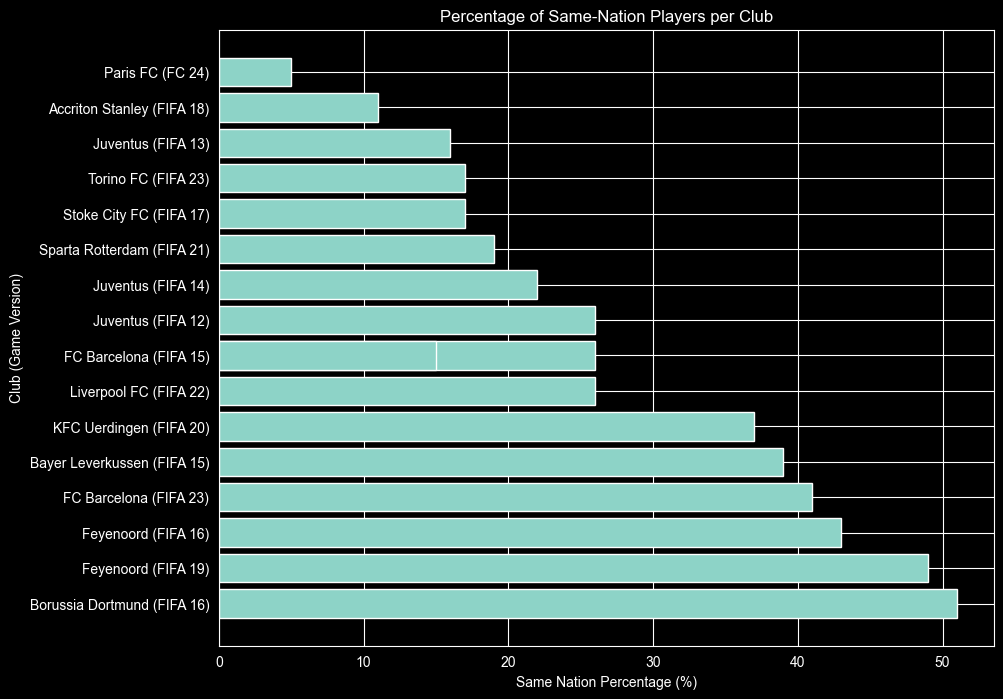

In [25]:
df_same_nation_players = df_person_info[["uuid", "country_uuid", "career_mode_uuid"]].rename(
    columns={"uuid": "player_uuid", "country_uuid": "player_country_uuid"})

# Add Career Mode information
df_same_nation_players = df_same_nation_players.merge(
    df_career_modes[["uuid", "club_uuid", "game_version_uuid"]].rename(
        columns={"uuid": "career_mode_uuid"}),
    left_on="career_mode_uuid",
    right_on="career_mode_uuid",
    )

# Add Club information
df_same_nation_players = df_same_nation_players.merge(
    df_clubs[["uuid", "name", "country_uuid"]].rename(
        columns={"uuid": "club_uuid", "name": "club_name", "country_uuid": "club_country_uuid"}),
    left_on="club_uuid",
    right_on="club_uuid",
)

# Add game version information
df_same_nation_players = df_same_nation_players.merge(
    df_game_versions[["uuid", "name"]].rename(
        columns={"uuid": "game_version_uuid", "name": "game_version_name"}),
    left_on="game_version_uuid",
    right_on="game_version_uuid",
)

# Add player and club country name
df_same_nation_players = df_same_nation_players.merge(
    df_countries[["uuid", "name"]].rename(
        columns={"uuid": "player_country_uuid", "name": "player_country_name"}),
    left_on="player_country_uuid",
    right_on="player_country_uuid",
)
df_same_nation_players = df_same_nation_players.merge(
    df_countries[["uuid", "name"]].rename(
        columns={"uuid": "club_country_uuid", "name": "club_country_name"}),
    left_on="club_country_uuid",
    right_on="club_country_uuid",
)

# All column that defines if player is the same nation as the club
df_same_nation_players["is_home_nation"] = (
    df_same_nation_players["player_country_uuid"] == df_same_nation_players["club_country_uuid"]
)

df_same_nation_per_club_career = (
    df_same_nation_players
        .groupby(["career_mode_uuid", "club_name", "game_version_name"])
        ["is_home_nation"]
        .sum()  # counts True as 1
        .reset_index(name="same_nation_players")
        .sort_values("same_nation_players", ascending=False)
)
# Combine club_name and game_version_name into one column for simplicity
df_same_nation_per_club_career["club_game"] = (
        df_same_nation_per_club_career["club_name"] + " (" + df_same_nation_per_club_career["game_version_name"] + ")"
)

# Make the dataframe simpler
df_same_nation_per_club_career = df_same_nation_per_club_career[["career_mode_uuid", "club_game", "same_nation_players"]]

# Merge the player per career mode dataframe to get the total player per career mode value
df_same_nation_per_club_career = df_same_nation_per_club_career.merge(
    df_player_per_career_mode[["career_mode_uuid", "player_count"]],
    left_on="career_mode_uuid",
    right_on="career_mode_uuid",
    how="left"
)

df_same_nation_per_club_career["same_nation_percentage"] = (
    round((df_same_nation_per_club_career["same_nation_players"] / df_same_nation_per_club_career["player_count"]) * 100, 0))

df_same_nation_per_club_career = df_same_nation_per_club_career.sort_values("same_nation_percentage", ascending=False)

# Graph
plt.figure(figsize=(10, 8))
plt.barh(df_same_nation_per_club_career["club_game"], df_same_nation_per_club_career["same_nation_percentage"])
plt.xlabel("Same Nation Percentage (%)")
plt.ylabel("Club (Game Version)")
plt.title("Percentage of Same-Nation Players per Club")
plt.show()